## 0. 설정

In [1]:
<< mTensor`

In [2]:
$PreRead = 
  ReplaceAll[#, 
    expr_String :> StringReplace[expr,
    "TMP" -> "mTensor`Private"]] &;

In [3]:
DefineKind[Alphabet["Greek"], Greek];
DefineKind[ToUpperCase /@ Alphabet[], Capital]

## 1. DnUpPair and UpDnPair

### 1.1 markPairs

In [6]:
Tdefine[T, "abcd"];

In [7]:
T[ub, lc, ld, lb]

T[ub, lc, ld, lb]

In [8]:
TMP`markPairs[List@%, {}, {}]

{T[$upup[mTensor`Private`xx$7340$7342][Latin][ub], lc, ld, 
 
>    $upup[mTensor`Private`xx$7340$7342][Latin][lb]]}

### 1.2 DnUpPair

인덱스 쌍의 순서를 (가능하면) Dn-Up으로 재조정한다. 옵션으로 `HeadQs`, `CovDs`가 있다.

인덱스 쌍이 한 텐서 안에 있는 경우

In [9]:
Tdefine[Z, "*"]; Z[ub, lc, ld, lb]

Z[ub, lc, ld, lb]

In [10]:
DnUpPair[%]

Z[lb, lc, ld, ub]

연산자가 있는 경우

In [11]:
BD[ua, CD[ub, Z[la, lb, lc, ud]]]

BD[ua, CD[ub, Z[la, lb, lc, ud]]]

In [12]:
DnUpPair[%]

BD[ua, CD[lb, Z[la, ub, lc, ud]]]

In [13]:
CD[ua, CD[ub, Z[la, lb, lc, ud]]]

CD[ua, CD[ub, Z[la, lb, lc, ud]]]

In [14]:
DnUpPair[%]

CD[la, CD[lb, Z[ua, ub, lc, ud]]]

In [15]:
CD[ua, LD[V, Z[la, ud, le, lf]]] v[ld]

CD[ua, LD[V, Z[la, ud, le, lf]]] v[ld]

In [16]:
DnUpPair[%]  (* LD[v,T[indices]] =!= LD[v,T][indices] *)

CD[ua, LD[V, Z[la, ud, le, lf]]] v[ld]

잘못된 입력:

In [17]:
expr = BD[ua, CD[ub, Z[lc, lb, ld, ue]]] v[lb]

BD[ua, CD[ub, Z[lc, lb, ld, ue]]] v[lb]

In [18]:
DnUpPair[%]

BD[ua, CD[lb, Z[lc, ub, ld, ue]]] v[lb]

공변 도함수가 아니라도 dn-up 순서를 바꾸려면 option으로 지정하면 된다.

In [19]:
CD[ua, BD[la, Z[ub, ld, le, lf]]] v[lb]

CD[ua, BD[la, Z[ub, ld, le, lf]]] v[lb]

In [20]:
DnUpPair[%]

CD[la, BD[ua, Z[ub, ld, le, lf]]] v[lb]

In [21]:
DnUpPair[%%, CovDs -> {CD, BD}]

CD[la, BD[ua, Z[ub, ld, le, lf]]] v[lb]

In [22]:
Tdefine[Z[lA], "*"]; Tdefine[v[lA], "a"]

In [23]:
expr = CD[uA, CD[uB, Z[lA, lB, lE, lF]]] BD[uC, v[lD]] v[lC]

BD[uC, v[lD]] CD[uA, CD[uB, Z[lA, lB, lE, lF]]] v[lC]

In [24]:
DnUpPair[expr]  (* No Capital's metric *)

BD[uC, v[lD]] CD[uA, CD[uB, Z[lA, lB, lE, lF]]] v[lC]

In [25]:
DefineMetric[Phi, Capital]

In [26]:
DnUpPair[expr]

BD[lC, v[lD]] CD[uA, CD[uB, Z[lA, lB, lE, lF]]] v[uC]

In [27]:
RemoveMetric[Phi]

In [28]:
Tdefine[Z, "*"]; Tdefine[v, "a"]

CovDs option으로 지정하는 연산자는 미리 정의되어 있어야 한다.

In [29]:
DnUpPair[expr, CovDs -> {nonOP}]

`1` `2` `3` `4`: not defined operator(s) {nonOP}  

BD[uC, v[lD]] CD[uA, CD[uB, Z[lA, lB, lE, lF]]] v[lC]

### 1.3 UpDnPair

인덱스 쌍의 순서를 (가능하면) Up-Dn으로 재조정한다. 옵션으로 `HeadQs`, `CovDs`가 있다.

인덱스 쌍이 한 텐서 안에 있는 경우

In [30]:
Z[lb, lc, ld, ub]

Z[lb, lc, ld, ub]

In [31]:
UpDnPair[%]

Z[ub, lc, ld, lb]

연산자가 있는 경우

In [32]:
BD[la, CD[lb, Z[ua, ub, lc, ud]]]

BD[la, CD[lb, Z[ua, ub, lc, ud]]]

In [33]:
UpDnPair[%]

BD[la, CD[ub, Z[ua, lb, lc, ud]]]

In [34]:
CD[la, CD[lb, Z[ua, ub, lc, ud]]]

CD[la, CD[lb, Z[ua, ub, lc, ud]]]

In [35]:
UpDnPair[%]

CD[ua, CD[ub, Z[la, lb, lc, ud]]]

In [36]:
CD[la, LD[V, Z[ua, ld, le, lf]]] v[ud]

CD[la, LD[V, Z[ua, ld, le, lf]]] v[ud]

In [37]:
UpDnPair[%]  (* LD[v,T[indices]] =!= LD[v,T][indices] *)

CD[la, LD[V, Z[ua, ld, le, lf]]] v[ud]

잘못된 입력:

In [38]:
expr = BD[la, CD[lb, Z[lc, ub, ld, ue]]] v[ub]

BD[la, CD[lb, Z[lc, ub, ld, ue]]] v[ub]

In [39]:
UpDnPair[%]

`1` `2` `3` `4`: duplicated indices: {la, lb, lc, ub, ld, ue, ub}  

ErrorT[BD[la, CD[lb, Z[lc, ub, ld, ue]]] v[ub]]

공변 도함수가 아니라도 dn-up 순서를 바꾸려면 option으로 지정하면 된다.

In [40]:
CD[la, BD[ua, Z[lb, ld, le, lf]]] v[ub]

CD[la, BD[ua, Z[lb, ld, le, lf]]] v[ub]

In [41]:
UpDnPair[%]

CD[ua, BD[la, Z[lb, ld, le, lf]]] v[ub]

In [42]:
UpDnPair[%%, CovDs -> {CD, BD}]

CD[ua, BD[la, Z[ub, ld, le, lf]]] v[lb]

반대칭 metric인 경우:

In [43]:
Tdefine[Z[lA], "*"];
Tdefine[v[lA], "a"];
DefineDerivativeOperator[CovD, "D", Capital]

In [46]:
DefineMetric[Phi, Capital, -1]

In [47]:
MakeMetricConnection[CovD, Phi]

In [48]:
TMP`getMetricSymmetry[Phi]

-1

In [49]:
{CD[lA, Z[uA, uB, uC]] v[lC], CovD[uA, Z[lA, uB, uC]] v[lC], 
 CovD[uA, Z[lA, uB, lC]] v[uC]}

{CD[lA, Z[uA, uB, uC]] v[lC], CovD[uA, Z[lA, uB, uC]] v[lC], 
 
>   CovD[uA, Z[lA, uB, lC]] v[uC]}

In [50]:
UpDnPair /@ %

{CD[lA, Z[uA, uB, uC]] v[lC], CovD[uA, Z[lA, uB, uC]] v[lC], 
 
>   -(CovD[uA, Z[lA, uB, uC]] v[lC])}

In [51]:
DnUpPair /@ %%

{CD[lA, Z[uA, uB, uC]] v[lC], CovD[lA, Z[uA, uB, lC]] v[uC], 
 
>   -(CovD[lA, Z[uA, uB, lC]] v[uC])}

In [52]:
v[lA] v[uA]

v[lA] v[uA]

In [53]:
UpDnPair[v[lA] v[uA]]  (* 0 *)

-(v[lA] v[uA])

In [54]:
RemoveMetric[Phi]

In [55]:
Tdefine[Z, "*"]; Tdefine[v, "a"]

## 2. Rules for Simplification

### 2.1 BDinvgRule

In [56]:
BD[la, Metricg[ub, uc]]

BD[la, Metricg[ub, uc]]

In [57]:
% /. BDinvgRule[]

-(BD[la, Metricg[ld, le]] Metricg[ub, ud] Metricg[uc, ue])

In [58]:
%% /. BDinvgRule[Metricg]

-(BD[la, Metricg[ld, le]] Metricg[ub, ud] Metricg[uc, ue])

### 2.2 KdeltaSumRule

In [59]:
Kdelta[la, lb] /. KdeltaSumRule[]

Kdelta[la, lb]

In [60]:
Kdelta[la, ua] /. KdeltaSumRule[]

GetDimension[Latin]

In [61]:
Kdelta[ua, la] /. KdeltaSumRule[]

GetDimension[Latin]

In [62]:
Kdelta[lA, uA] /. KdeltaSumRule[]

Kdelta[lA, uA]

In [63]:
Kdelta[lA, uA] /. KdeltaSumRule[Capital]

GetDimension[Capital]

In [64]:
DefineMetric[Eps, "\[Epsilon]", Capital, -1]

In [65]:
Kdelta[lA, uA] /. KdeltaSumRule[Capital]

-GetDimension[Capital]

In [66]:
Kdelta[lA, uA] /. KdeltaSumRule[nonKind]

Kdelta[lA, uA]

### 2.3 EpsilonProductRule

In [67]:
GetSignature[Latin] = s; GetDimension[Latin] = n;

In [68]:
Epsilon[ua, ub] EpsilonGreek[l\[Mu], l\[Nu]] /. EpsilonProductRule[]

Epsilon[ua, ub] EpsilonGreek[lμ, lν]

In [69]:
Epsilon[ua, ub] Epsilon[lc, ld] /. EpsilonProductRule[]

n - s                                   n - s
-(I      Kdelta[lc, ub] Kdelta[ld, ua]) + I      Kdelta[lc, ua] Kdelta[ld, ub]

In [70]:
Epsilon[ua, ub, up] Epsilon[lc, ld, lp] /. EpsilonProductRule[]

n - s                                  n - s
2 I      Kdelta[lc, ub] Kdelta[ld, ua] - I      n Kdelta[lc, ub] Kdelta[ld, ua] - 
 
       n - s                                  n - s
>   2 I      Kdelta[lc, ua] Kdelta[ld, ub] + I      n Kdelta[lc, ua] Kdelta[ld, ub]

In [71]:
% // Simplify

n - s
-(I      (-2 + n) Kdelta[lc, ub] Kdelta[ld, ua]) + 
 
     n - s
>   I      (-2 + n) Kdelta[lc, ua] Kdelta[ld, ub]

In [72]:
DefineMetric[g, Greek]

In [73]:
EpsilonGreek[u\[Mu], u\[Nu]] EpsilonGreek[l\[Rho], l\[Sigma]] /. 
 EpsilonProductRule[Greek]

GetDimension[Greek] - GetSignature[Greek]
-(I                                          Kdelta[lρ, uν] Kdelta[lσ, uμ]) + 
 
     GetDimension[Greek] - GetSignature[Greek]
>   I                                          Kdelta[lρ, uμ] Kdelta[lσ, uν]

In [74]:
Tdefine[A, "*-"]

In [75]:
SetDimension[4]

A[ua, ub] Epsilon[la, lb, lc, ld]
---------------------------------
                2
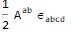

In [76]:
DualStar[A[ua, ub], {la, lb, lc, ld}]

A[ua, ub] Epsilon[la, lb, lc, ld] Epsilon[uc, ud, ue, uf]
---------------------------------------------------------
                            4
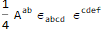

In [77]:
DualStar[%, {uc, ud, ue, uf}]

4 - s              4 - s
I      A[ue, uf]   I      A[uf, ue]
---------------- - ----------------
       2                  2
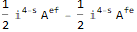

In [78]:
% /. EpsilonProductRule[]

In [79]:
% // TindexSort

4 - s
I      A[ue, uf]

A[ua, ub, uc] Epsilon[la, lb, lc, ld]
-------------------------------------
                  6
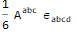

In [80]:
DualStar[A[ua, ub, uc], {la, lb, lc, ld}]

A[ua, ub, uc] Epsilon[la, lb, lc, ld] Epsilon[ud, ue, uf, ug]
-------------------------------------------------------------
                              6
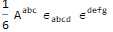

In [81]:
DualStar[%, {ud, ue, uf, ug}]

4 - s                   4 - s                  4 - s
-(I      A[ue, uf, ug])   I      A[ue, ug, uf]   I      A[uf, ue, ug]
----------------------- + -------------------- + -------------------- - 
           6                       6                      6
 
     4 - s                  4 - s                  4 - s
    I      A[uf, ug, ue]   I      A[ug, ue, uf]   I      A[ug, uf, ue]
>   -------------------- - -------------------- + --------------------
             6                      6                      6
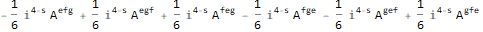

In [82]:
% /. EpsilonProductRule[]

In [83]:
% // TindexSort

4 - s
-(I      A[ue, uf, ug])

## 3. TindexSort

In [84]:
Tdefine[\[Epsilon], "*-"]; Tdefine[A, "-ba"]; Tdefine[S, "ba"]

In [85]:
TindexSort /@ {A[la, lb], A[lb, la], A[ua, la]}

{A[la, lb], -A[la, lb], 0}

In [86]:
TindexSort /@ {S[la, lb], S[lb, la], S[ua, la]}

{S[la, lb], S[la, lb], S[la, ua]}

In [87]:
TindexSort /@ {\[Epsilon][], \[Epsilon][la], \[Epsilon][lb, 
   la], \[Epsilon][lc, lb, la], \[Epsilon][ua, lb, la]}

{ϵ[], ϵ[la], -ϵ[la, lb], -ϵ[la, lb, lc], 0}

In [88]:
TindexSort /@ {A[-2, -1], A[1, -1], A[1, 1], A[-1, -1], A[2, 1]}

{-A[-1, -2], -A[-1, 1], 0, 0, -A[1, 2]}

In [89]:
TindexSort[S[lc, la, lb]]

mTensor`Private`errObject[ErrorT[S][lc, la, lb]]

In [90]:
TindexSort /@ {S[lc, lc], S[uc, lc]}

{mTensor`Private`errObject[ErrorT[S][lc, lc]], S[lc, uc]}

In [91]:
TindexSort /@ {BD[lb, ua, A[ub, la]], BD[ub, la, A[lb, ua]], 
  BD[lb, la, A[ub, ua]]}

{-BD[lb, BD[ua, A[la, ub]]], -BD[ub, BD[la, A[ua, lb]]], 0}

In [92]:
TindexSort /@ {BD[lb, ua, S[ub, la]], BD[ub, la, S[lb, ua]], 
  BD[lb, la, S[ub, ua]]}

{BD[lb, BD[ua, S[la, ub]]], BD[ub, BD[la, S[ua, lb]]], BD[la, BD[lb, S[ua, ub]]]}

Antisymmetric metric:

In [93]:
DefineMetric[Eps, "\[Epsilon]", Capital, -1]

In [94]:
On[CoordinateBasisFlag[Capital]]

In [95]:
Tdefine[CA[lA, lB], "A", "-ba"]; Tdefine[CS[lA, lB], "S", "ba"];

In [96]:
{CA[uA, lA], CA[1, 1], CA[-1, 1]} // TindexSort

{-CA[lA, uA], 0, CA[-1, 1]}

In [97]:
{CS[uA, lA], CS[1, 1], CS[-1, 1]} // TindexSort

{0, CS[1, 1], CS[-1, 1]}

In [98]:
TindexSort /@ {BD[lB, uA, CA[uB, lA]], BD[uB, lA, CA[lB, uA]], 
  BD[lB, lA, CA[uB, uA]]}

{-BD[lB, BD[uA, CA[lA, uB]]], -BD[uB, BD[lA, CA[uA, lB]]], 0}

In [99]:
TindexSort /@ {BD[lB, uA, CS[uB, lA]], BD[uB, lA, CS[lB, uA]], 
  BD[lB, lA, CS[uB, uA]]}

{BD[lB, BD[uA, CS[lA, uB]]], BD[uB, BD[lA, CS[uA, lB]]], BD[lA, BD[lB, CS[uA, uB]]]}

## 4. Tsimplify

In [100]:
Tdefine[T, "*"]; Tdefine[f[]]; Tdefine[v, "a"];
Tdefine[A, "-ba"]; Tdefine[B, "ab"];
Tdefine[S, "ba"]; Tdefine[F, "-ba"]

대칭 메트릭을 갖는 시공간에서의 텐서 표현을 `TensorReduce`를 이용하여 간단화 시킨다. Option으로는 `HeadQs`와 `CovDs`가 있다.

### 4.1 제한 사항

In [103]:
DefineMetric[Eps, "\[Epsilon]", Capital, -1]

In [104]:
Tsimplify[Eps[lA, lB] Eps[uA, uC]]

`1` `2` `3` `4`: There is non-symmetric metric when contracting indices.   

Eps[lA, lB] Eps[uA, uC]

### 4.2 Single Tensor

In [105]:
{A[ua, ub], A[lb, ub], A[lb, la], S[ub, ua], S[ua, la]}

{A[ua, ub], A[lb, ub], A[lb, la], S[ub, ua], S[ua, la]}

In [106]:
Tsimplify[%] // ResetDummies

{A[ua, ub], 0, -A[la, lb], S[ua, ub], S[la, ua]}

In [107]:
{S[1, 1], F[1, 1], F[1, -1]}

{S[1, 1], F[1, 1], F[1, -1]}

In [108]:
Tsimplify[%]

{S[1, 1], 0, -F[-1, 1]}

In [109]:
{CD[la, lb, A[ua, ub]], CD[la, lb, S[ua, ub]],
 CD[la, lc, A[ua, ub]]}

{CD[la, CD[lb, A[ua, ub]]], CD[la, CD[lb, S[ua, ub]]], CD[la, CD[lc, A[ua, ub]]]}

In [110]:
Tsimplify[%] // ResetDummies

{CD[la, CD[lb, A[ua, ub]]], CD[la, CD[lb, S[ua, ub]]], -CD[la, CD[lc, A[ub, ua]]]}

In [111]:
Tsimplify[BD[la, lb, A[ua, lb]]]  (* errObject *)

mTensor`Private`errObject[ErrorT[BD][la, BD[lb, A[ua, lb]]]]

In [112]:
{BD[la, ub, A[ua, lb]], BD[la, lb, A[ub, ua]],
 BD[ua, lb, A[ub, la]]}

{BD[la, BD[ub, A[ua, lb]]], BD[la, BD[lb, A[ub, ua]]], BD[ua, BD[lb, A[ub, la]]]}

In [113]:
Tsimplify[%] // ResetDummies

{BD[la, BD[ub, A[ua, lb]]], 0, BD[ua, BD[lb, A[ub, la]]]}

### 4.3 Tensor Product

#### 4.3.1 Two Tensors

In [114]:
A[la, lb] S[ua, ub]

A[la, lb] S[ua, ub]

In [115]:
Tsimplify[%]

0

In [116]:
expr = {S[la, lb]  BD[lc, A[ua, ub]],
         S[la, ub]  CD[lc, A[ua, lb]],
         S[la, ub]  BD[lc, A[ua, lb]]}

{BD[lc, A[ua, ub]] S[la, lb], CD[lc, A[ua, lb]] S[la, ub], BD[lc, A[ua, lb]] S[la, ub]}

In [117]:
Tsimplify[expr] // ResetDummies

{0, 0, BD[lc, A[ua, lb]] S[la, ub]}

In [118]:
TorsionFreeQ[CD] = False;

In [119]:
expr = {CD[la, lb, f[]] A[ua, ub],
         CD[la, lb, S[lc, ld]] A[ua, ub]}

{A[ua, ub] CD[la, CD[lb, f[]]], A[ua, ub] CD[la, CD[lb, S[lc, ld]]]}

In [120]:
Tsimplify[expr] // ResetDummies

{A[la, lb] CD[ua, CD[ub, f[]]], A[la, lb] CD[ua, CD[ub, S[lc, ld]]]}

In [121]:
TorsionFreeQ[CD] = True;

In [122]:
Tsimplify[expr] // ResetDummies

{0, A[la, lb] CD[ua, CD[ub, S[lc, ld]]]}

In [123]:
expr = {CD[la, ub, f[]] A[ua, lb],
         BD[lc, CD[la, ub, f[]]] A[ua, lb]}

{A[ua, lb] CD[la, CD[ub, f[]]], A[ua, lb] BD[lc, CD[la, CD[ub, f[]]]]}

In [124]:
Tsimplify[expr] // ResetDummies

{0, A[ua, lb] BD[lc, CD[la, CD[ub, f[]]]]}

In [125]:
ToCanonical[expr] // ResetDummies

{0, A[ua, lb] BD[lc, CD[la, CD[ub, f[]]]]}

In [126]:
expr = {BD[la, lb, f[]] A[ua, ub],
         BD[la, lb, S[uc, ud]] A[ua, ub],
         BD[lc, ua, lb, S[ud, ue]] A[la, ub],
         CD[lc, BD[ua, lb, S[ud, ue]]] A[la, ub],
         CD[lc, BD[la, ub, S[ud, ue]]] A[ua, lb]}

{A[ua, ub] BD[la, BD[lb, f[]]], A[ua, ub] BD[la, BD[lb, S[uc, ud]]], 
 
>   A[la, ub] BD[lc, BD[ua, BD[lb, S[ud, ue]]]], 
 
>   A[la, ub] CD[lc, BD[ua, BD[lb, S[ud, ue]]]], 
 
>   A[ua, lb] CD[lc, BD[la, BD[ub, S[ud, ue]]]]}

In [127]:
Tsimplify[expr] // ResetDummies (* The fourth should be zero! *)

{0, 0, A[la, ub] BD[lc, BD[ua, BD[lb, S[ud, ue]]]], 
 
>   A[la, ub] CD[lc, BD[ua, BD[lb, S[ud, ue]]]], 
 
>   A[ua, lb] CD[lc, BD[la, BD[ub, S[ud, ue]]]]}

In [128]:
PutMetric[%[[4]], ua] // Absorbg

A[ua, ub] CD[lc, BD[la, BD[lb, S[ud, ue]]]]

In [129]:
Tsimplify[%]

0

Kind를 고려

In [130]:
SetDefaultKind[Capital]

In [131]:
Tdefine[A[lA, lB], "-ba"]; Tdefine[S[lA, lB], "ba"]

In [132]:
expr = {S[la, ub]  CD[lc, A[ua, lb]],
         S[la, uB]  CD[lc, A[ua, lB]],
         S[la, uB]  CD[lC, A[ua, lB]],
         S[lA, uB]  CD[lC, A[uA, lB]]}

{CD[lc, A[ua, lb]] S[la, ub], CD[lc, A[ua, lB]] S[la, uB], CD[lC, A[ua, lB]] S[la, uB], 
 
>   CD[lC, A[uA, lB]] S[lA, uB]}

In [133]:
Tsimplify[expr] // ResetDummies

{mTensor`Private`errObject[ErrorT[CD][lc, A[ua, lb]]] 
 
>    mTensor`Private`errObject[ErrorT[S][la, ub]], 
 
>   mTensor`Private`errObject[ErrorT[CD][lc, A[ua, lB]]] 
 
>    mTensor`Private`errObject[ErrorT[S][la, uB]], 
 
>   mTensor`Private`errObject[ErrorT[CD][lC, ErrorT[A][ua, lB]]] 
 
>    mTensor`Private`errObject[ErrorT[S][la, uB]], 0}

In [134]:
expr = {S[lA, uB]  CD[lc, A[uA, lB]],
         S[lA, uB]  CD[lC, A[uA, lB]],
         S[lA, uB]  BD[lc, A[uA, lB]]}

{CD[lc, A[uA, lB]] S[lA, uB], CD[lC, A[uA, lB]] S[lA, uB], BD[lc, A[uA, lB]] S[lA, uB]}

In [135]:
Tsimplify[expr] // ResetDummies

{mTensor`Private`errObject[ErrorT[CD][lc, A[uA, lB]]] S[lA, uB], 0, 
 
>   BD[lc, A[uA, lB]] S[lA, uB]}

In [136]:
expr = {CD[la, lb, f[]] A[ua, ub], CD[lA, lB, f[]] A[uA, uB]}

{A[ua, ub] CD[la, CD[lb, f[]]], A[uA, uB] CD[lA, CD[lB, f[]]]}

In [137]:
Tsimplify[expr] // ResetDummies

{mTensor`Private`errObject[ErrorT[A][ua, ub]] 
 
>    mTensor`Private`errObject[ErrorT[CD][la, CD[lb, f[]]]], 0}

In [138]:
expr = {CD[la, ub, f[]] A[ua, lb], CD[la, uB, f[]] A[ua, lB]}

{A[ua, lb] CD[la, CD[ub, f[]]], A[ua, lB] CD[la, CD[uB, f[]]]}

In [139]:
Tsimplify[expr] // ResetDummies

{mTensor`Private`errObject[ErrorT[A][ua, lb]] 
 
>    mTensor`Private`errObject[ErrorT[CD][la, CD[ub, f[]]]], 
 
>   mTensor`Private`errObject[ErrorT[A][ua, lB]] 
 
>    mTensor`Private`errObject[ErrorT[CD][la, CD[uB, f[]]]]}

In [140]:
expr = {CD[lA, uB, f[]] A[uA, lB],
         BD[lc, CD[lA, uB, f[]]] A[uA, lB]}

{A[uA, lB] CD[lA, CD[uB, f[]]], A[uA, lB] BD[lc, CD[lA, CD[uB, f[]]]]}

In [141]:
Tsimplify[expr] // ResetDummies

{0, A[uA, lB] BD[lc, CD[lA, CD[uB, f[]]]]}

In [142]:
expr = {BD[la, lb, S[lc, ld]] A[ua, ub],
         BD[lA, lB, S[lc, ld]] A[uA, uB],
         BD[lA, lB, S[lC, lD]] A[uA, uB]}

{A[ua, ub] BD[la, BD[lb, S[lc, ld]]], A[uA, uB] BD[lA, BD[lB, S[lc, ld]]], 
 
>   A[uA, uB] BD[lA, BD[lB, S[lC, lD]]]}

In [143]:
Tsimplify[expr] // ResetDummies

{mTensor`Private`errObject[ErrorT[A][ua, ub]] 
 
>    mTensor`Private`errObject[ErrorT[BD][la, ErrorT[BD][lb, ErrorT[S][lc, ld]]]], 
 
>   A[uA, uB] mTensor`Private`errObject[ErrorT[BD][lA, 
 
>      ErrorT[BD][lB, ErrorT[S][lc, ld]]]], 0}

In [144]:
expr = {BD[ua, lb, S[lc, ld]] A[la, ub],
         BD[ua, lB, S[lc, ld]] A[la, uB]}

{A[la, ub] BD[ua, BD[lb, S[lc, ld]]], A[la, uB] BD[ua, BD[lB, S[lc, ld]]]}

In [145]:
Tsimplify[expr] // ResetDummies

{mTensor`Private`errObject[ErrorT[A][la, ub]] 
 
>    mTensor`Private`errObject[ErrorT[BD][ua, ErrorT[BD][lb, ErrorT[S][lc, ld]]]], 
 
>   mTensor`Private`errObject[ErrorT[A][la, uB]] 
 
>    mTensor`Private`errObject[ErrorT[BD][ua, ErrorT[BD][lB, ErrorT[S][lc, ld]]]]}

In [146]:
expr = {BD[uA, lB, S[lc, ld]] A[lA, uB],
         BD[uA, lB, S[lC, lD]] A[lA, uB],
         BD[lA, uB, S[lc, ld]] A[uA, lB]}

{A[lA, uB] BD[uA, BD[lB, S[lc, ld]]], A[lA, uB] BD[uA, BD[lB, S[lC, lD]]], 
 
>   A[uA, lB] BD[lA, BD[uB, S[lc, ld]]]}

In [147]:
Tsimplify[expr] // ResetDummies

{A[lA, uB] mTensor`Private`errObject[ErrorT[BD][uA, ErrorT[BD][lB, ErrorT[S][lc, ld]]]], 
 
>   A[lA, uB] BD[uA, BD[lB, S[lC, lD]]], 
 
>   A[uA, lB] mTensor`Private`errObject[ErrorT[BD][lA, 
 
>      ErrorT[BD][uB, ErrorT[S][lc, ld]]]]}

In [148]:
expr = {BD[la, BD[uA, lB, S[lc, ld]]] A[lA, uB],
         CD[la, BD[uA, lB, S[lc, ld]]] A[lA, uB],
         CD[la, BD[uA, lB, S[lC, lD]]] A[lA, uB],
         CD[lE, BD[uA, lB, S[lC, lD]]] A[lA, uB]}

{A[lA, uB] BD[la, BD[uA, BD[lB, S[lc, ld]]]], 
 
>   A[lA, uB] CD[la, BD[uA, BD[lB, S[lc, ld]]]], 
 
>   A[lA, uB] CD[la, BD[uA, BD[lB, S[lC, lD]]]], 
 
>   A[lA, uB] CD[lE, BD[uA, BD[lB, S[lC, lD]]]]}

In [149]:
Tsimplify[expr] // ResetDummies

{A[lA, uB] mTensor`Private`errObject[ErrorT[BD][la, 
 
>      ErrorT[BD][uA, ErrorT[BD][lB, ErrorT[S][lc, ld]]]]], 
 
>   A[lA, uB] mTensor`Private`errObject[ErrorT[CD][la, BD[uA, BD[lB, S[lc, ld]]]]], 
 
>   A[lA, uB] mTensor`Private`errObject[ErrorT[CD][la, BD[uA, BD[lB, S[lC, lD]]]]], 
 
>   A[lA, uB] CD[lE, BD[uA, BD[lB, S[lC, lD]]]]}

In [150]:
SetDefaultKind[Latin]  (* default *)

In [151]:
Tdefine[A, "-ba"]; Tdefine[S, "ba"]

#### 4.3.2 Three Tensors

In [152]:
expr = {A[ua, ub] v[la] v[lb], A[ua, lb] v[la] v[ub],
         A[ua, lb] v[la] CD[lc, v[ub]],
         A[ua, lb] CD[uc, v[la]] CD[lc, v[ub]]}

{A[ua, ub] v[la] v[lb], A[ua, lb] v[la] v[ub], A[ua, lb] CD[lc, v[ub]] v[la], 
 
>   A[ua, lb] CD[lc, v[ub]] CD[uc, v[la]]}

In [153]:
Tsimplify[expr] // ResetDummies

{0, 0, A[la, lb] CD[lc, v[ub]] v[ua], 0}

In [154]:
expr = {A[la, lb] B[ua, lc] B[ub, uc],
         A[la, lb] B[ua, lc] B[ub, ud]}

{A[la, lb] B[ua, lc] B[ub, uc], A[la, lb] B[ua, lc] B[ub, ud]}

In [155]:
Tsimplify[expr] // ResetDummies

{0, A[la, lb] B[ua, lc] B[ub, ud]}

In [156]:
expr = {A[ua, ub] BD[ld, B[la, lc]] BD[ud, B[lb, uc]],
         A[ua, ub] CD[ld, B[la, lc]] CD[ud, B[lb, uc]],
         A[ua, ub] CD[ld, B[la, lc]] B[lb, uc]}

{A[ua, ub] BD[ld, B[la, lc]] BD[ud, B[lb, uc]], 
 
>   A[ua, ub] CD[ld, B[la, lc]] CD[ud, B[lb, uc]], A[ua, ub] B[lb, uc] CD[ld, B[la, lc]]}

In [157]:
Tsimplify[expr] // ResetDummies

{A[ua, ub] BD[lc, B[la, ld]] BD[uc, B[lb, ud]], 0, 
 
>   -(A[la, lb] B[ua, lc] CD[ld, B[ub, uc]])}

In [158]:
expr = {A[ua, lb] BD[la, f[]] BD[ub, f[]],
         A[ua, ub] BD[la, v[lc]] BD[lb, v[uc]],
         A[ua, ub] CD[la, v[lc]] CD[lb, v[uc]]}

{A[ua, lb] BD[la, f[]] BD[ub, f[]], A[ua, ub] BD[la, v[lc]] BD[lb, v[uc]], 
 
>   A[ua, ub] CD[la, v[lc]] CD[lb, v[uc]]}

In [159]:
Tsimplify[expr] // ResetDummies

{0, A[ua, ub] BD[la, v[lc]] BD[lb, v[uc]], 0}

In [160]:
expr = {A[ua, ub] BD[la, B[lc, ld]] BD[lb, B[uc, ud]],
         A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[uc, ud]],
         A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[ud, uc]]}

{A[ua, ub] BD[la, B[lc, ld]] BD[lb, B[uc, ud]], 
 
>   A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[uc, ud]], 
 
>   A[ua, ub] CD[la, B[lc, ld]] CD[lb, B[ud, uc]]}

In [161]:
Tsimplify[expr] // ResetDummies

{A[ua, ub] BD[la, B[lc, ld]] BD[lb, B[uc, ud]], 0, 0}

In [162]:
expr = {A[la, lb] CD[le, ua, B[lc, ld]] CD[lf, ub, B[uc, ud]],
         A[la, lb] CD[le, ua, B[lc, ld]] CD[ue, ub, B[uc, ud]]}

{A[la, lb] CD[le, CD[ua, B[lc, ld]]] CD[lf, CD[ub, B[uc, ud]]], 
 
>   A[la, lb] CD[le, CD[ua, B[lc, ld]]] CD[ue, CD[ub, B[uc, ud]]]}

In [163]:
Tsimplify[expr] // ResetDummies

{A[la, lb] CD[le, CD[ua, B[lc, ld]]] CD[lf, CD[ub, B[uc, ud]]], 0}

In [164]:
{A[ua, ub] BD[la, Metricg[lc, ld]] BD[lb, Metricg[uc, ud]],
 A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[ue, BD[lb, Metricg[uc, ud]]]}

{A[ua, ub] BD[la, Metricg[lc, ld]] BD[lb, Metricg[uc, ud]], 
 
>   A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[ue, BD[lb, Metricg[uc, ud]]]}

In [165]:
Tsimplify[%] // ResetDummies

{A[ua, ub] BD[la, Metricg[lc, ld]] BD[lb, Metricg[ud, uc]], 
 
>   A[ua, ub] CD[lc, BD[la, Metricg[ld, le]]] CD[uc, BD[lb, Metricg[ud, ue]]]}

In [166]:
Tsimplify[%% /. BDinvgRule[]]

{0, 0}

In [167]:
expr = {A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[lf, 
    BD[lb, Metricg[uc, ud]]], 
  A[ua, ub] BD[le, BD[la, Metricg[lc, ld]]] BD[ue, 
    BD[lb, Metricg[uc, ud]]]}

{A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[lf, BD[lb, Metricg[uc, ud]]], 
 
>   A[ua, ub] BD[le, BD[la, Metricg[lc, ld]]] BD[ue, BD[lb, Metricg[uc, ud]]]}

In [168]:
Tsimplify[expr] // ResetDummies

{A[ua, ub] CD[le, BD[la, Metricg[lc, ld]]] CD[lf, BD[lb, Metricg[ud, uc]]], 
 
>   A[ua, ub] BD[la, BD[lc, Metricg[ld, le]]] BD[uc, BD[lb, Metricg[ud, ue]]]}

### 4.4 Multi-Terms

In [169]:
expr = {B[la, ua] + B[ua, la],
         CD[la, lb, B[ua, ub]] + CD[lc, ld, B[uc, ud]]}

{B[la, ua] + B[ua, la], CD[la, CD[lb, B[ua, ub]]] + CD[lc, CD[ld, B[uc, ud]]]}

In [170]:
Tsimplify[expr] // ResetDummies

{2 B[la, ua], 2 CD[la, CD[lb, B[ua, ub]]]}

In [171]:
expr = {B[la, lb] B[ua, ub] + B[lc, ld] B[uc, ud],
         B[la, lb] B[ub, ua] + B[la, lb] B[ua, ub],
         B[lc, la] B[uc, lb] + B[lc, lb] B[uc, la]}

{B[la, lb] B[ua, ub] + B[lc, ld] B[uc, ud], B[la, lb] B[ua, ub] + B[la, lb] B[ub, ua], 
 
>   B[lc, lb] B[uc, la] + B[lc, la] B[uc, lb]}

In [172]:
Tsimplify[expr] // ResetDummies

{2 B[la, lb] B[ua, ub], B[la, lb] B[ua, ub] + B[la, lb] B[ub, ua], 2 B[lc, la] B[uc, lb]}

In [173]:
expr = {S[la, uc] S[lc, lb] + S[le, la] S[lb, ue],
         RiemannCD[la, lb, ld, le] S[ua, ue] +
         RiemannCD[lb, le, lc, ld] S[ue, uc]}

{S[la, uc] S[lc, lb] + S[lb, ue] S[le, la], 
 
>   RiemannCD[la, lb, ld, le] S[ua, ue] + RiemannCD[lb, le, lc, ld] S[ue, uc]}

In [174]:
Tsimplify[expr] // ResetDummies

{2 S[la, lc] S[lb, uc], -2 RiemannCD[lb, la, ld, lc] S[ua, uc]}

In [175]:
CD[la, lb, F[ua, ub]]

CD[la, CD[lb, F[ua, ub]]]

In [176]:
expr = CDtoGamma[CDtoGamma[%]]

BD[la, BD[lb, F[ua, ub]]] + BD[la, GammaCD[lb, lc, ub]] F[ua, uc] + 
 
>   BD[la, GammaCD[lb, lc, ua]] F[uc, ub] + BD[lb, F[uc, ub]] GammaCD[la, lc, ua] + 
 
>   BD[la, F[uc, ub]] GammaCD[lb, lc, ua] + BD[la, F[ua, uc]] GammaCD[lb, lc, ub] + 
 
>   F[uc, ub] GammaCD[la, ld, ua] GammaCD[lb, lc, ud] + 
 
>   F[uc, ud] GammaCD[la, lc, ua] GammaCD[lb, ld, ub]

In [177]:
Tsimplify[expr]

-(BD[la, GammaCD[lb, lc, uc]] F[ub, ua])

In [178]:
expr = RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] RiemannCD[
    ua, ub, ue, uf] + 
  RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, 
    ud, ue, uf]

RiemannCD[la, lb, lc, ld] RiemannCD[le, lf, uc, ud] RiemannCD[ua, ub, ue, uf] + 
 
>   RiemannCD[lc, ld, ug, uh] RiemannCD[le, lf, lg, lh] RiemannCD[uc, ud, ue, uf]

In [179]:
Tsimplify[expr]

2 RiemannCD[la, lb, lc, ld] RiemannCD[ua, ub, le, lf] RiemannCD[uc, ud, ue, uf]

In [180]:
CD[ua, S[lb, la]] CD[ub, f[]] + CD[ub, S[lb, la]] CD[ua, f[]]

CD[ua, S[lb, la]] CD[ub, f[]] + CD[ua, f[]] CD[ub, S[lb, la]]

In [181]:
Tsimplify[%]

2 CD[la, f[]] CD[lb, S[ua, ub]]